# Avance 2. Ingeniería de características (Feature Engineering)

**Sistema Inteligente para la Optimización de Operaciones de Transporte mediante Inteligencia Artificial aplicada al Análisis Predictivo de Datos GPS**

Maestría en Inteligencia Artificial Aplicada, TC5035 — Equipo 56

**Equipo**
- Alejandra Guadalupe Larrañaga Altamirano, A01794334
- Mario Alberto Guillén De La Torre, A01796701
- Andrea Kimberly Fray Tamayo, A01797168

**Fecha:** 11 de octubre de 2026

---

## Objetivo de esta fase

Este notebook continúa directamente el Avance 1. Se parte de `../data/processed/trips_clean.csv`, donde ya se realizaron la limpieza, tratamiento de faltantes, reglas de atípicos y codificación básica.

En esta fase se realiza ingeniería de características, seguida de selección mediante métodos de filtrado.

**Variable objetivo:** `duration_seconds`, problema de regresión.

> Importante: no se utilizan como variables predictoras `ended_at`, `duration_seconds`, `average_speed`, `max_speed`, `stops_count` ni `stopped_seconds`, porque son información posterior o resultado del viaje. Tampoco se usa `data_source`, ya que identifica nuestro pipeline de datos y no una característica disponible en producción.


## 1. Carga y revisión del dataset del Avance 1

El Avance 1 ya produjo el dataset limpio. Aqui no se repiten las etapas de limpieza, unicamente se verifica que las columnas necesarias esten disponibles y que la variable objetivo sea continua

In [3]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_selection import VarianceThreshold, mutual_info_regression

#from google.colab import drive
#drive.mount('/content/drive')

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

IN_COLAB = "google.colab" in sys.modules

# Fuente del dataset limpio del Avance 1:
# 1) trips_clean.csv: existe si se acaba de ejecutar el Avance 1 en esta máquina (versión más reciente).
# 2) trips_clean.csv.gz: copia comprimida versionada en el repositorio, permite ejecutar
#    este notebook de forma independiente sin regenerar el Avance 1.
CLEAN_PATH = "../data/processed/trips_clean.csv"
CLEAN_PATH_GZ = "../data/processed/trips_clean.csv.gz"

if os.path.exists(CLEAN_PATH):
    df = pd.read_csv(CLEAN_PATH)
    print(f"Dataset cargado desde {CLEAN_PATH}")
elif os.path.exists(CLEAN_PATH_GZ):
    df = pd.read_csv(CLEAN_PATH_GZ, compression="gzip")
    print(f"Dataset cargado desde {CLEAN_PATH_GZ}")
elif IN_COLAB:
    print("No se encontró el dataset limpio. Sube trips_clean.csv o trips_clean.csv.gz manualmente:")
    from google.colab import files
    uploaded = files.upload()
    fname = list(uploaded.keys())[0]
    df = pd.read_csv(fname)
else:
    raise FileNotFoundError(
        "No se encontró el dataset limpio. Ejecuta este notebook desde la carpeta "
        "notebooks/ del repositorio, o ejecuta primero el Avance 1."
    )

print("Dimensiones:", df.shape)
print("Columnas:")
print(df.columns.tolist())
display(df.head())


Dataset cargado desde ../data/processed/trips_clean.csv
Dimensiones: (436807, 71)
Columnas:
['vehicle_id', 'started_at', 'ended_at', 'duration_seconds', 'distance_km', 'average_speed', 'max_speed', 'stops_count', 'stopped_seconds', 'data_source', 'origin_zone', 'destination_zone', 'origin_zone_id', 'destination_zone_id', 'corridor', 'hour_of_day', 'day_of_week', 'previous_trip_duration', 'historical_corridor_mean_duration', 'orig_Akumal', 'orig_Boca Paila', 'orig_Calica', 'orig_Cancun', 'orig_Chetumal', 'orig_Chichen Itza', 'orig_Chiquila', 'orig_Costa Mujeres', 'orig_Cozumel', 'orig_Kantenah', 'orig_Maroma Beach', 'orig_Merida', 'orig_Paamul', 'orig_Paraiso Beach', 'orig_Playa Del Carmen', 'orig_Playa Mujeres', 'orig_Playacar', 'orig_Puerto Aventuras', 'orig_Puerto Juarez', 'orig_Puerto Morelos', 'orig_Tankah', 'orig_Tulum', 'orig_Tulum Hotel Zone', 'orig_Valladolid', 'orig_Xcaret', 'orig_Xpu Ha', 'dest_Akumal', 'dest_Boca Paila', 'dest_Calica', 'dest_Cancun', 'dest_Chetumal', 'dest_C

,vehicle_id,started_at,ended_at,duration_seconds,distance_km,average_speed,max_speed,stops_count,stopped_seconds,data_source,origin_zone,destination_zone,origin_zone_id,destination_zone_id,corridor,hour_of_day,day_of_week,previous_trip_duration,historical_corridor_mean_duration,orig_Akumal,orig_Boca Paila,orig_Calica,orig_Cancun,orig_Chetumal,orig_Chichen Itza,orig_Chiquila,orig_Costa Mujeres,orig_Cozumel,orig_Kantenah,orig_Maroma Beach,orig_Merida,orig_Paamul,orig_Paraiso Beach,orig_Playa Del Carmen,orig_Playa Mujeres,orig_Playacar,orig_Puerto Aventuras,orig_Puerto Juarez,orig_Puerto Morelos,orig_Tankah,orig_Tulum,orig_Tulum Hotel Zone,orig_Valladolid,orig_Xcaret,orig_Xpu Ha,dest_Akumal,dest_Boca Paila,dest_Calica,dest_Cancun,dest_Chetumal,dest_Chichen Itza,dest_Chiquila,dest_Costa Mujeres,dest_Cozumel,dest_Kantenah,dest_Maroma Beach,dest_Merida,dest_Paamul,dest_Paraiso Beach,dest_Playa Del Carmen,dest_Playa Mujeres,dest_Playacar,dest_Puerto Aventuras,dest_Puerto Juarez,dest_Puerto Morelos,dest_Tankah,dest_Tulum,dest_Tulum Hotel Zone,dest_Valladolid,dest_Xcaret,dest_Xpu Ha
0,1,2026-09-25 16:29:37+00:00,2026-09-25 16:38:38+00:00,541,2.643,17.312506,43.000016,0.0,0.0,real,Cancun,Cancun,NaN,NaN,Cancun → Cancun,11,4,3857.0,3932.083333,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,1,2026-09-25 18:24:35+00:00,2026-09-25 19:38:06+00:00,4411,7.208,13.770786,52.000019,5.0,802.0,real,Cancun,Cancun,NaN,NaN,Cancun → Cancun,13,4,541.0,541.000000,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,1,2026-09-25 20:01:18+00:00,2026-09-25 22:08:06+00:00,7608,19.750,23.562359,70.000025,13.0,1054.0,real,Cancun,Cancun,NaN,NaN,Cancun → Cancun,15,4,4411.0,2476.000000,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,1,2026-09-27 19:44:05+00:00,2026-09-27 20:22:57+00:00,2332,4.674,16.452921,54.000020,5.0,233.0,real,Cancun,Cancun,NaN,NaN,Cancun → Cancun,14,6,7608.0,4186.666667,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,1,2026-09-28 15:05:32+00:00,2026-09-28 16:56:24+00:00,6652,9.370,15.320394,49.000018,3.0,337.0,real,Cancun,Cancun,NaN,NaN,Cancun → Cancun,10,0,2332.0,3723.000000,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## 2. Definición de la variable objetivo y separación entrenamiento/prueba

Como el objetivo es predecir la duracion de un viaje, `duration_seconds` se mantiene unicamente como target. La separacion se realiza antes de ajustar transformaciones que aprendan estadisticas de los datos.

Se utiliza una separacion temporal aproximada: los primeros 80% de viajes ordenados por `started_at` forman entrenamiento y el 20% final prueba.

In [5]:
TARGET = "duration_seconds"

excluded = [
    TARGET, "ended_at", "average_speed", "max_speed",
    "stops_count", "stopped_seconds", "data_source"
]

df = df.sort_values("started_at").reset_index(drop=True)

split_idx = int(len(df) * 0.80)
train_raw = df.iloc[:split_idx].copy()
test_raw = df.iloc[split_idx:].copy()

print(f"Train: {train_raw.shape}")
print(f"Test : {test_raw.shape}")
print(f"Periodo train: {train_raw['started_at'].min()} -> {train_raw['started_at'].max()}")
print(f"Periodo test : {test_raw['started_at'].min()} -> {test_raw['started_at'].max()}")


Train: (349445, 71)
Test : (87362, 71)
Periodo train: 2026-09-25 16:29:37+00:00 -> 2026-10-27 14:00:00+00:00
Periodo test : 2026-10-27 14:00:00+00:00 -> 2026-11-02 04:00:00+00:00


## 3. Generación de nuevas características

Se generan variables que representan patrones relevantes para el problema de transporte:

1. **Características cíclicas del tiempo:** `hour_sin`, `hour_cos`, `dow_sin`, `dow_cos`. La hora 23 y la hora 0 son cercanas, aunque numéricamente esten separadas.
2. **Fin de semana:** `is_weekend`, util para representar cambios de operacion entre dias laborales y fin de semana.
3. **Horario de mayor demanda:** `is_rush_hour`, usando una regla de dominio (07–09 y 16–18).
4. **Transformación logaritmica de distancia:** `distance_log1p`. Se incluye como alternativa a `distance_km` para representar posibles relaciones no lineales. No se transforma la variable objetivo, porque en el Avance 1 se observo que `log(duration_seconds + 1)` empeoraba la forma de la distribución.
5. **Binning de distancia:** `distance_bin`. Se calculan los puntos de corte con cuantiles del conjunto de entrenamiento y se aplican sin volver a estimarlos en prueba. Esto permite representar efectos no lineales por rangos de distancia.

No se generan variables a partir de `duration_seconds` ni de informacin posterior al inicio del viaje.

In [7]:
def add_features(data, distance_bins=None):
    out = data.copy()

    # Tiempo ciclico
    out["hour_sin"] = np.sin(2 * np.pi * out["hour_of_day"] / 24)
    out["hour_cos"] = np.cos(2 * np.pi * out["hour_of_day"] / 24)
    out["dow_sin"] = np.sin(2 * np.pi * out["day_of_week"] / 7)
    out["dow_cos"] = np.cos(2 * np.pi * out["day_of_week"] / 7)

    # Indicadores de calendario/operacion
    out["is_weekend"] = (out["day_of_week"] >= 5).astype("int8")
    out["is_rush_hour"] = (
        out["hour_of_day"].between(7, 9) |
        out["hour_of_day"].between(16, 18)
    ).astype("int8")

    # Transformación de distancia
    out["distance_log1p"] = np.log1p(out["distance_km"])

    # Binning: los cortes se calculan solo en train
    if distance_bins is None:
        q = out["distance_km"].quantile([0, .25, .50, .75, 1]).values
        distance_bins = np.unique(q)

    # Si hay pocos valores únicos, usamos una discretización robusta alternativa
    if len(distance_bins) >= 3:
        labels = [f"bin_{i+1}" for i in range(len(distance_bins)-1)]
        out["distance_bin"] = pd.cut(
            out["distance_km"],
            bins=distance_bins,
            labels=labels,
            include_lowest=True,
            duplicates="drop"
        )
    else:
        out["distance_bin"] = "bin_unico"

    return out, distance_bins

train_fe, distance_bins = add_features(train_raw)
test_fe, _ = add_features(test_raw, distance_bins=distance_bins)

print("Cortes de distance_bin calculados en train:")
print(np.round(distance_bins, 3))
display(train_fe[[
    "distance_km", "distance_log1p", "hour_of_day", "hour_sin", "hour_cos",
    "day_of_week", "dow_sin", "dow_cos", "is_weekend", "is_rush_hour",
    "distance_bin"
]].head())


Cortes de distance_bin calculados en train:
[  1.66   38.251  83.832 157.225 419.835]


,distance_km,distance_log1p,hour_of_day,hour_sin,hour_cos,day_of_week,dow_sin,dow_cos,is_weekend,is_rush_hour,distance_bin
0,2.643,1.292808,11,0.258819,-0.965926,4,-0.433884,-0.900969,0,0,bin_1
1,7.208,2.105109,13,-0.258819,-0.965926,4,-0.433884,-0.900969,0,0,bin_1
2,19.750,3.032546,15,-0.707107,-0.707107,4,-0.433884,-0.900969,0,0,bin_1
3,4.674,1.735894,14,-0.500000,-0.866025,6,-0.781831,0.623490,1,0,bin_1
4,9.370,2.338917,10,0.500000,-0.866025,0,0.000000,1.000000,0,0,bin_1


### 3.1 Evaluación de la transformación logaritmica

La transformacion logaritmica se conserva como caracterstica candidata, la decisión final se tomará después de revisar correlación e información mutua.

Esto evita asumir que una transformacion es util unicamente por ser una tecnica estandar: debe aportar información adicional al modelo.

,feature,skew_train,corr_target
0,distance_km,1.099358,0.980980
1,distance_log1p,-0.549614,0.895918


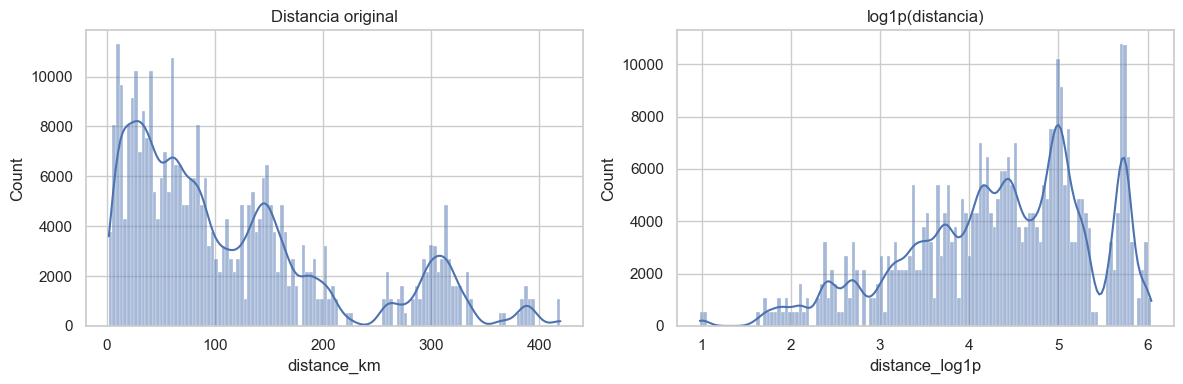

In [9]:
comparison = pd.DataFrame({
    "feature": ["distance_km", "distance_log1p"],
    "skew_train": [
        train_fe["distance_km"].skew(),
        train_fe["distance_log1p"].skew()
    ],
    "corr_target": [
        train_fe["distance_km"].corr(train_fe[TARGET]),
        train_fe["distance_log1p"].corr(train_fe[TARGET])
    ]
})
display(comparison)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(train_fe["distance_km"], kde=True, ax=axes[0])
axes[0].set_title("Distancia original")
sns.histplot(train_fe["distance_log1p"], kde=True, ax=axes[1])
axes[1].set_title("log1p(distancia)")
plt.tight_layout()
plt.show()


## 4. Codificación de variables categóricas

Las zonas de origen y destino se codifican a partir de `origin_zone_id` y `destination_zone_id` (26 zonas operativas), y no a partir de los nombres `origin_zone` / `destination_zone`. El motivo es que en los datos sintéticos solo existe el identificador de zona y el nombre aparece únicamente en los viajes reales; si se codificara el nombre, la categoría "sin nombre" equivaldría a marcar si el viaje es sintético, lo que reintroduce de forma indirecta la variable `data_source` que se excluyó desde el inicio.

Los identificadores se convierten de flotante a entero (vienen como `float` porque la columna contiene nulos) para que las columnas resultantes sean legibles (`origin_zone_id_5` en lugar de `origin_zone_id_5.0`). Los 7 viajes reales del piloto GPS sin zona asignada (0.002% del dataset) se agrupan en la categoría `sin_zona`, en lugar de eliminarlos, para conservar los únicos registros reales disponibles.

Las zonas y `distance_bin` son variables nominales sin una distancia numérica natural entre categorías, por lo que se utiliza **One-Hot Encoding**, evitando imponer un orden artificial. El codificador se ajusta solamente con entrenamiento y `handle_unknown="ignore"` permite que una categoría nueva aparezca en prueba o en producción sin romper el pipeline.

In [11]:
#categorical_features = ["origin_zone", "destination_zone", "distance_bin"]
categorical_features = [
    "origin_zone_id",
    "destination_zone_id",
    "distance_bin"
]

# Zonas: de float a entero en texto; los viajes reales sin zona quedan como "sin_zona"
for data in (train_fe, test_fe):
    for col in ["origin_zone_id", "destination_zone_id"]:
        data[col] = data[col].apply(
            lambda v: "sin_zona" if pd.isna(v) else str(int(v))
        )

print("Viajes sin zona asignada en train:", (train_fe["origin_zone_id"] == "sin_zona").sum())
print("Viajes sin zona asignada en test :", (test_fe["origin_zone_id"] == "sin_zona").sum())

numeric_features = [
    "distance_km", "distance_log1p",
    "hour_sin", "hour_cos", "dow_sin", "dow_cos",
    "is_weekend", "is_rush_hour"
]

# VerificaciOn
missing_required = [c for c in categorical_features + numeric_features + [TARGET] if c not in train_fe.columns]
if missing_required:
    raise ValueError(f"Faltan columnas requeridas: {missing_required}")

print("Categóricas:", categorical_features)
print("Numéricas:", numeric_features)

Viajes sin zona asignada en train: 7
Viajes sin zona asignada en test : 0
Categóricas: ['origin_zone_id', 'destination_zone_id', 'distance_bin']
Numéricas: ['distance_km', 'distance_log1p', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'is_weekend', 'is_rush_hour']


In [12]:
encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

X_train_cat = encoder.fit_transform(train_fe[categorical_features])
X_test_cat = encoder.transform(test_fe[categorical_features])

encoded_columns = encoder.get_feature_names_out(categorical_features)

X_train_cat = pd.DataFrame(
    X_train_cat,
    columns=encoded_columns,
    index=train_fe.index
)

X_test_cat = pd.DataFrame(
    X_test_cat,
    columns=encoded_columns,
    index=test_fe.index
)

print("Variables categóricas originales:", len(categorical_features))
print("Variables después de One-Hot:", len(encoded_columns))

display(X_train_cat.head())

Variables categóricas originales: 3
Variables después de One-Hot: 58


,origin_zone_id_1,origin_zone_id_10,origin_zone_id_11,origin_zone_id_12,origin_zone_id_13,origin_zone_id_14,origin_zone_id_15,origin_zone_id_16,origin_zone_id_17,origin_zone_id_18,origin_zone_id_19,origin_zone_id_2,origin_zone_id_20,origin_zone_id_21,origin_zone_id_22,origin_zone_id_23,origin_zone_id_24,origin_zone_id_25,origin_zone_id_26,origin_zone_id_27,origin_zone_id_3,origin_zone_id_4,origin_zone_id_5,origin_zone_id_6,origin_zone_id_7,origin_zone_id_8,origin_zone_id_sin_zona,destination_zone_id_1,destination_zone_id_10,destination_zone_id_11,destination_zone_id_12,destination_zone_id_13,destination_zone_id_14,destination_zone_id_15,destination_zone_id_16,destination_zone_id_17,destination_zone_id_18,destination_zone_id_19,destination_zone_id_2,destination_zone_id_20,destination_zone_id_21,destination_zone_id_22,destination_zone_id_23,destination_zone_id_24,destination_zone_id_25,destination_zone_id_26,destination_zone_id_27,destination_zone_id_3,destination_zone_id_4,destination_zone_id_5,destination_zone_id_6,destination_zone_id_7,destination_zone_id_8,destination_zone_id_sin_zona,distance_bin_bin_1,distance_bin_bin_2,distance_bin_bin_3,distance_bin_bin_4
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0


## 5. Escalamiento

Se utiliza estandarización (`StandardScaler`) para las variables numéricas. Esto centra cada variable en media 0 y desviación estándar 1.

La estandarizacion es especialmente importante antes de PCA, porque PCA depende de la varianza y una variable con unidades o escala mayor podria dominar los componentes.

In [14]:
numeric_scaler = StandardScaler()
X_train_num = numeric_scaler.fit_transform(train_fe[numeric_features])
X_test_num = numeric_scaler.transform(test_fe[numeric_features])

print("Media aproximada de train después de estandarizar:")
print(np.round(X_train_num.mean(axis=0), 4))
print("Desviación estándar aproximada:")
print(np.round(X_train_num.std(axis=0), 4))


Media aproximada de train después de estandarizar:
[-0. -0.  0.  0. -0.  0.  0. -0.]
Desviación estándar aproximada:
[1. 1. 1. 1. 1. 1. 1. 1.]


## 6. Métodos de filtrado para selección de características

Se aplican tres criterios complementarios:

### 6.1 Umbral de varianza
Elimina variables constantes o prácticamente constantes. Una característica sin variabilidad no puede discriminar entre observaciones. Se usa como filtro inicial y no depende de la variable objetivo.

### 6.2 Correlacion entre caracteristicas
Se buscan pares de variables numericas con correlacion absoluta alta (`|r| > 0.90`). El objetivo es reducir redundancia. En particular, `distance_km` y `distance_log1p` pueden contener prácticamente la misma señal.

### 6.3 Informacion mutua con el target
La información mutua permite detectar relaciones potencialmente no lineales entre una característica y la duración. Es apropiada como complemento de la correlación, que solo mide dependencia lineal.

La selección se hace sobre entrenamiento para evitar que información del conjunto de prueba influya en las decisiones de modelado.

In [16]:
# 6.1 Umbral de varianza
binary_and_numeric = numeric_features.copy()
X_var = train_fe[binary_and_numeric].copy()

vt = VarianceThreshold(threshold=0.0)
vt.fit(X_var)

kept_var = X_var.columns[vt.get_support()].tolist()
removed_var = [c for c in X_var.columns if c not in kept_var]

print("Características conservadas por variance threshold:")
print(kept_var)
print("\nCaracterísticas eliminadas por varianza cero:")
print(removed_var if removed_var else "Ninguna")


Características conservadas por variance threshold:
['distance_km', 'distance_log1p', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'is_weekend', 'is_rush_hour']

Características eliminadas por varianza cero:
Ninguna


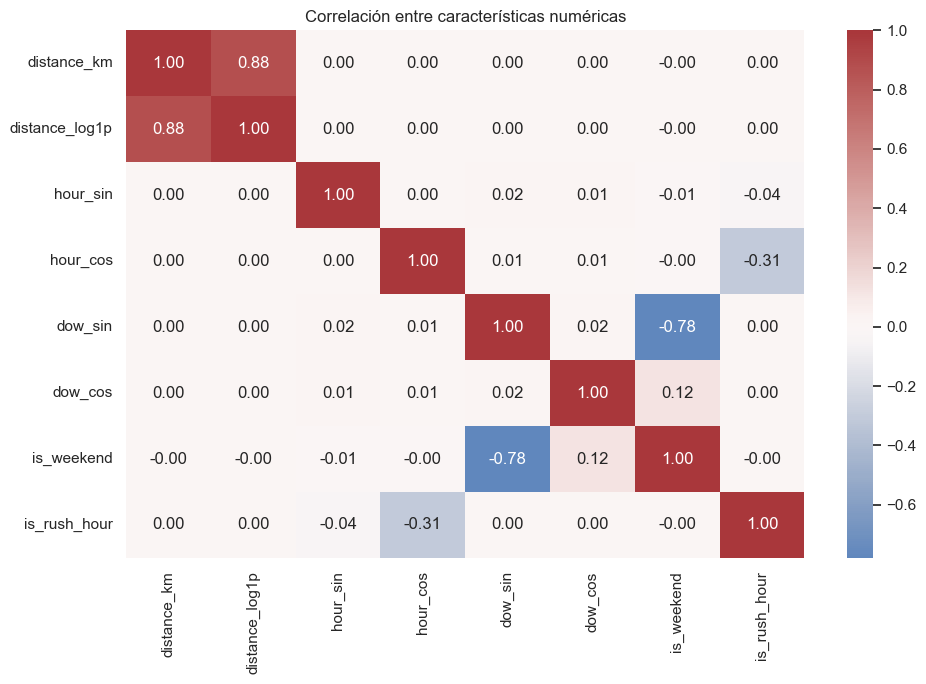

Variables eliminadas por |correlación| > 0.9 :
Ninguna

Variables numéricas después del filtro de correlación:
['distance_km', 'distance_log1p', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'is_weekend', 'is_rush_hour']


In [17]:
# 6.2 Correlacion entre variables numéricas
corr = train_fe[kept_var].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Correlación entre características numéricas")
plt.tight_layout()
plt.show()

threshold_corr = 0.90
to_drop_corr = set()

for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        if abs(corr.iloc[i, j]) > threshold_corr:
            a, b = corr.columns[i], corr.columns[j]
            # Conservamos la variable original/interpretable cuando existe
            if a == "distance_log1p" and b == "distance_km":
                to_drop_corr.add(a)
            elif b == "distance_log1p" and a == "distance_km":
                to_drop_corr.add(b)
            else:
                # En otros pares, se elimina la segunda por simplicidad reproducible
                to_drop_corr.add(b)

print("Variables eliminadas por |correlación| >", threshold_corr, ":")
print(sorted(to_drop_corr) if to_drop_corr else "Ninguna")

filtered_numeric = [c for c in kept_var if c not in to_drop_corr]
print("\nVariables numéricas después del filtro de correlación:")
print(filtered_numeric)


,mutual_information
distance_log1p,2.400394
distance_km,2.384854
hour_cos,0.038369
dow_sin,0.032334
hour_sin,0.031303
dow_cos,0.014207
is_weekend,0.004222
is_rush_hour,0.003097


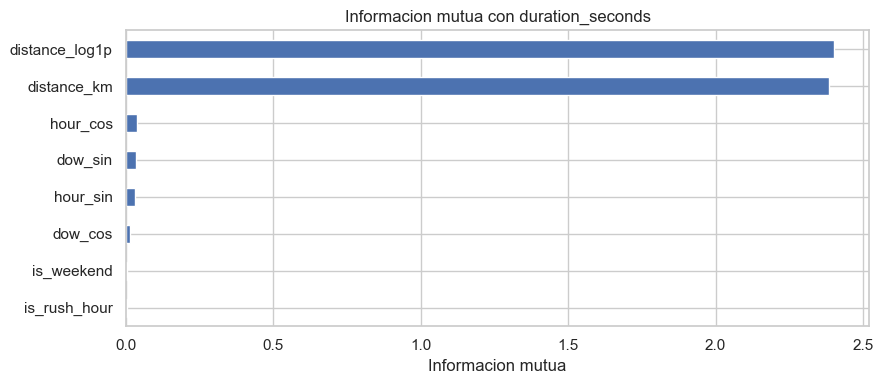

In [18]:
# 6.3 Información mutua con la duración
mi_train = train_fe[filtered_numeric + [TARGET]].dropna()

mi = mutual_info_regression(
    mi_train[filtered_numeric],
    mi_train[TARGET],
    random_state=42
)

mi_result = (
    pd.Series(mi, index=filtered_numeric)
      .sort_values(ascending=False)
      .rename("mutual_information")
)

display(mi_result.to_frame())

plt.figure(figsize=(9, 4))
mi_result.sort_values().plot(kind="barh")
plt.title("Informacion mutua con duration_seconds")
plt.xlabel("Informacion mutua")
plt.tight_layout()
plt.show()


### 6.4 ANOVA para variables categóricas y prueba F para numéricas

La información mutua se calculó solo para las variables numéricas. Para evaluar las categóricas se utiliza **ANOVA de un factor**: compara la duración media del viaje entre las categorías de cada variable (por ejemplo, entre las 26 zonas de origen). Si las medias difieren significativamente, la variable aporta información sobre el target. Como complemento, para las numéricas se utiliza la prueba F de regresión (`f_regression`), que es el equivalente de ANOVA para una variable continua.

Con más de 349 mil viajes en entrenamiento, prácticamente cualquier diferencia resulta estadísticamente significativa (p ≈ 0), por lo que el valor p por sí solo no permite distinguir variables útiles de variables marginales. Por ello se reporta también el **tamaño del efecto eta² (η²)**, que indica qué proporción de la varianza de la duración explica cada variable categórica.

No se utiliza chi-cuadrado porque requiere que tanto la característica como el target sean categóricos, y la duración es una variable continua.


In [33]:
from scipy.stats import f_oneway
from sklearn.feature_selection import f_regression

# ANOVA de un factor para variables categóricas (solo con entrenamiento)
def anova_eta2(data, feature, target):
    groups = [g[target].values for _, g in data.groupby(feature, observed=True)]
    f_stat, p_value = f_oneway(*groups)
    grand_mean = data[target].mean()
    ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups)
    ss_total = ((data[target] - grand_mean) ** 2).sum()
    return f_stat, p_value, ss_between / ss_total, len(groups)

anova_rows = []
for feat in categorical_features:
    f_stat, p_value, eta2, k = anova_eta2(train_fe, feat, TARGET)
    anova_rows.append({"feature": feat, "categorias": k, "F": f_stat, "p_value": p_value, "eta2": eta2})

anova_result = pd.DataFrame(anova_rows).sort_values("eta2", ascending=False)
display(anova_result.round(4))

# Prueba F de regresión para variables numéricas
f_num, p_num = f_regression(train_fe[filtered_numeric], train_fe[TARGET])
f_result = (
    pd.DataFrame({"feature": filtered_numeric, "F": f_num, "p_value": p_num})
      .sort_values("F", ascending=False)
)
display(f_result.round(4))

,feature,categorias,F,p_value,eta2
2,distance_bin,4,536718.8739,0.0,0.8217
0,origin_zone_id,27,8964.1583,0.0,0.4001
1,destination_zone_id,27,8752.0016,0.0,0.3944


,feature,F,p_value
0,distance_km,8.925042e+06,0.0
1,distance_log1p,1.421398e+06,0.0
3,hour_cos,1.223080e+03,0.0
4,dow_sin,6.744739e+02,0.0
2,hour_sin,5.739835e+02,0.0
5,dow_cos,4.646966e+02,0.0
6,is_weekend,2.111557e+02,0.0
7,is_rush_hour,2.029750e+02,0.0


**Interpretación.** Las tres variables categóricas son significativas y explican una proporción importante de la varianza de la duración: la zona de origen explica alrededor de 40% (η² ≈ 0.40) y la de destino alrededor de 39%, por lo que se conservan. `distance_bin` alcanza η² ≈ 0.82, pero esto no es información nueva: es una versión discretizada de `distance_km`, que ya está en el modelo como variable continua; su permanencia se decide en la sección 8.

En las numéricas, la distancia domina con un valor F del orden de millones, mientras que las variables de calendario se ubican entre 200 y 1,200. Son significativas, pero su aporte individual es marginal. Antes de decidir cuáles conservar, se evalúan en conjunto con PCA en la sección 7.



## 7. Análisis de componentes principales (PCA)

PCA transforma las variables numéricas en componentes no correlacionados, ordenados por la varianza que explican. Se utiliza aquí con dos propósitos:

1. **Extracción:** evaluar si es posible representar las variables numéricas con menos dimensiones sin perder información, lo que reduciría almacenamiento y tiempo de entrenamiento.
2. **Diagnóstico de redundancia:** las cargas (*loadings*) de cada componente muestran qué variables comparten la misma señal, incluso cuando su correlación lineal no supera el umbral de 0.90 usado en la sección 6.2.

PCA se aplica sobre las variables numéricas **estandarizadas** de la sección 5, porque depende de la varianza: sin escalar, `distance_km` (cientos de kilómetros) dominaría los componentes solo por su escala. El ajuste se hace únicamente con entrenamiento.

No se aplica PCA a las columnas one-hot de zonas: son variables binarias y dispersas, y PCA supone variables continuas. Para ese caso la técnica adecuada sería el análisis de correspondencias múltiples (MCA), que excede el alcance de esta fase.



,componente,varianza_explicada,varianza_acumulada
0,PC1,0.235,0.235
1,PC2,0.223,0.459
2,PC3,0.164,0.622
3,PC4,0.127,0.750
4,PC5,0.123,0.873
5,PC6,0.086,0.959
6,PC7,0.026,0.985
7,PC8,0.015,1.000


Componentes necesarios para explicar al menos 95% de la varianza: 6 de 8


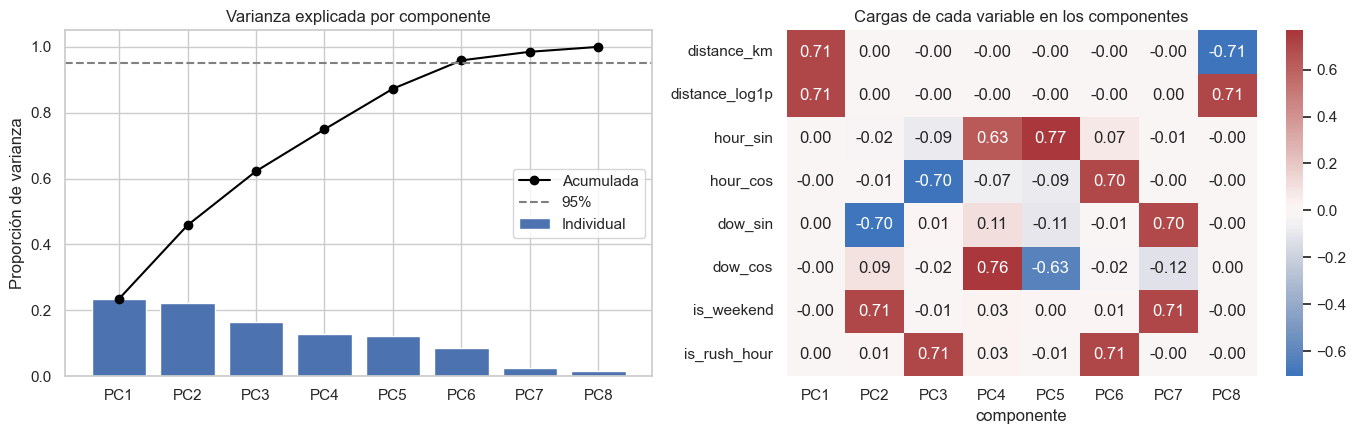

In [37]:
from sklearn.decomposition import PCA

pca = PCA(random_state=42)
pca.fit(X_train_num)

pca_variance = pd.DataFrame({
    "componente": [f"PC{i+1}" for i in range(len(numeric_features))],
    "varianza_explicada": pca.explained_variance_ratio_,
    "varianza_acumulada": np.cumsum(pca.explained_variance_ratio_)
})
display(pca_variance.round(3))

n_95 = int(np.argmax(pca_variance["varianza_acumulada"].values >= 0.95) + 1)
print(f"Componentes necesarios para explicar al menos 95% de la varianza: {n_95} de {len(numeric_features)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].bar(pca_variance["componente"], pca_variance["varianza_explicada"], label="Individual")
axes[0].plot(pca_variance["componente"], pca_variance["varianza_acumulada"], marker="o", color="black", label="Acumulada")
axes[0].axhline(0.95, linestyle="--", color="gray", label="95%")
axes[0].set_title("Varianza explicada por componente")
axes[0].set_ylabel("Proporción de varianza")
axes[0].legend()

loadings = pd.DataFrame(
    pca.components_.T,
    index=numeric_features,
    columns=pca_variance["componente"]
)
sns.heatmap(loadings, annot=True, fmt=".2f", cmap="vlag", center=0, ax=axes[1])
axes[1].set_title("Cargas de cada variable en los componentes")
plt.tight_layout()
plt.show()

### 7.1 Verificación: PCA sin las variables redundantes

Las cargas muestran que varios componentes se forman casi exclusivamente por un par de variables con peso similar (≈ 0.71 cada una). Para comprobar que esas variables son redundantes entre sí, se repite PCA eliminando de cada par la variable derivada: `distance_log1p` (transformación de `distance_km`), `is_weekend` (función de `day_of_week`, ya representado por `dow_sin` y `dow_cos`) e `is_rush_hour` (función de `hour_of_day`, ya representado por `hour_sin` y `hour_cos`).


In [40]:
redundant_by_pca = ["distance_log1p", "is_weekend", "is_rush_hour"]
reduced_numeric = [c for c in numeric_features if c not in redundant_by_pca]

reduced_idx = [numeric_features.index(c) for c in reduced_numeric]
pca_reduced = PCA(random_state=42).fit(X_train_num[:, reduced_idx])

pca_reduced_variance = pd.DataFrame({
    "componente": [f"PC{i+1}" for i in range(len(reduced_numeric))],
    "varianza_explicada": pca_reduced.explained_variance_ratio_,
    "varianza_acumulada": np.cumsum(pca_reduced.explained_variance_ratio_)
})
display(pca_reduced_variance.round(3))

n_95_reduced = int(np.argmax(pca_reduced_variance["varianza_acumulada"].values >= 0.95) + 1)
print(f"Variables numéricas: {len(numeric_features)} -> {len(reduced_numeric)}")
print(f"Componentes para 95% de varianza: {n_95_reduced} de {len(reduced_numeric)}")

,componente,varianza_explicada,varianza_acumulada
0,PC1,0.207,0.207
1,PC2,0.200,0.407
2,PC3,0.200,0.607
3,PC4,0.197,0.804
4,PC5,0.196,1.000


Variables numéricas: 8 -> 5
Componentes para 95% de varianza: 5 de 5


### 7.2 Decisión sobre PCA

**Como técnica de extracción, PCA no se incorpora al conjunto final.** Con las 8 variables numéricas se requieren 6 componentes para explicar 95% de la varianza, una reducción mínima. Más revelador es el resultado sin las variables redundantes: las 5 restantes reparten la varianza casi por igual (entre 19.6% y 20.7% cada componente), lo que indica que son prácticamente independientes entre sí y no existe una estructura de menor dimensión que comprimir. Además, sustituir variables interpretables (distancia, hora, día) por combinaciones lineales abstractas dificultaría explicar el modelo a la operación de Feraltar, y los modelos basados en árboles que se evaluarán en la siguiente fase no requieren variables descorrelacionadas.

**Como herramienta de diagnóstico, PCA sí fue determinante.** Las cargas revelaron tres pares redundantes que el filtro de correlación (|r| > 0.90) no detectó, porque su relación no es lineal:

- `distance_km` y `distance_log1p` forman por sí solas PC1 (carga ≈ 0.71 cada una). Su correlación de Pearson es 0.88, por debajo del umbral, pero `log1p` es una transformación monótona de la distancia: ordena los viajes exactamente igual.
- `dow_sin` e `is_weekend` forman PC2: el fin de semana es una función directa del día de la semana, que ya está representado con las variables cíclicas.
- `hour_cos` e `is_rush_hour` forman PC3: la hora pico es una función directa de la hora del día.

Los últimos tres componentes capturan justamente las diferencias dentro de cada par: PC6 (hora, 8.6% de la varianza), PC7 (día, 2.6%) y PC8 (distancia, 1.5%). Es decir, cada variable derivada agrega muy poca información respecto a su variable original. Con base en esta evidencia, en la sección 8 se eliminan `distance_log1p`, `is_weekend` e `is_rush_hour`.



## 8. Conjunto final de características

Con base en los resultados de las secciones 6 y 7, el conjunto final se define así:

| Variable | Decisión | Evidencia |
|---|---|---|
| `distance_km` | Se conserva | Mayor información mutua y prueba F; principal predictor de la duración |
| `hour_sin`, `hour_cos`, `dow_sin`, `dow_cos` | Se conservan | Aporte individual menor pero no redundante: PCA muestra que son prácticamente independientes entre sí |
| `origin_zone_id`, `destination_zone_id` (one-hot) | Se conservan | ANOVA: cada una explica cerca de 40% de la varianza de la duración (η² ≈ 0.40) |
| `distance_log1p` | Se elimina | Redundante con `distance_km` (PC1 y PC8 de PCA) |
| `is_weekend` | Se elimina | Redundante con `dow_sin` y `dow_cos` (PC2 y PC7) |
| `is_rush_hour` | Se elimina | Redundante con `hour_sin` y `hour_cos` (PC3 y PC6) |
| `distance_bin` (one-hot) | Se elimina | Es una versión discretizada de `distance_km`; la celda siguiente compara cuánta varianza explica cada una |

Las variables eliminadas se construyeron y evaluaron; su eliminación es resultado de las pruebas, no una decisión previa.


In [44]:
# distance_bin frente a distance_km: proporción de varianza de la duración que explica cada una
r2_distance_km = train_fe["distance_km"].corr(train_fe[TARGET]) ** 2
eta2_distance_bin = anova_result.set_index("feature").loc["distance_bin", "eta2"]
print(f"distance_km  (r²) : {r2_distance_km:.3f}")
print(f"distance_bin (η²) : {eta2_distance_bin:.3f}")

distance_km  (r²) : 0.962
distance_bin (η²) : 0.822


`distance_km` por sí sola explica una mayor proporción de la varianza que su versión discretizada, porque al agrupar la distancia en 4 rangos se pierde la variación dentro de cada rango. El binning tendría sentido para un modelo lineal que necesitara capturar efectos no lineales por tramos, pero los modelos basados en árboles que se evaluarán en la siguiente fase encuentran esos cortes por sí mismos a partir de la variable continua.

A continuación se construyen las matrices finales de entrenamiento y prueba: las variables numéricas conservadas (estandarizadas, con el escalador ajustado en la sección 5) y las columnas one-hot de zonas.


In [47]:
final_numeric = reduced_numeric
final_categorical = ["origin_zone_id", "destination_zone_id"]

# Numéricas: columnas conservadas de la matriz ya estandarizada (scaler ajustado solo con train)
num_idx = [numeric_features.index(c) for c in final_numeric]
X_train_num_final = pd.DataFrame(X_train_num[:, num_idx], columns=final_numeric, index=train_fe.index)
X_test_num_final = pd.DataFrame(X_test_num[:, num_idx], columns=final_numeric, index=test_fe.index)

# Categóricas: columnas one-hot de zonas (se descartan las de distance_bin)
zone_cols = [c for c in encoded_columns if c.startswith(tuple(final_categorical))]
# Las columnas one-hot solo valen 0 o 1: se guardan como int8 en lugar de float64 (8 veces menos memoria)
X_train_final = pd.concat([X_train_num_final, X_train_cat[zone_cols].astype("int8")], axis=1)
X_test_final = pd.concat([X_test_num_final, X_test_cat[zone_cols].astype("int8")], axis=1)
y_train = train_fe[TARGET]
y_test = test_fe[TARGET]

columns_before = len(numeric_features) + len(encoded_columns)
memory_before = (X_train_num.nbytes + X_train_cat.memory_usage(deep=True).sum()) / 1024**2
memory_after = X_train_final.memory_usage(deep=True).sum() / 1024**2

print(f"Características antes de la selección : {columns_before}")
print(f"Características después de la selección: {X_train_final.shape[1]}")
print(f"Memoria de X_train: {memory_before:.1f} MB -> {memory_after:.1f} MB")
print(f"\nX_train_final: {X_train_final.shape} | X_test_final: {X_test_final.shape}")
display(X_train_final.head())

Características antes de la selección : 66
Características después de la selección: 59
Memoria de X_train: 176.0 MB -> 31.3 MB

X_train_final: (349445, 59) | X_test_final: (87362, 59)


,distance_km,hour_sin,hour_cos,dow_sin,dow_cos,origin_zone_id_1,origin_zone_id_10,origin_zone_id_11,origin_zone_id_12,origin_zone_id_13,origin_zone_id_14,origin_zone_id_15,origin_zone_id_16,origin_zone_id_17,origin_zone_id_18,origin_zone_id_19,origin_zone_id_2,origin_zone_id_20,origin_zone_id_21,origin_zone_id_22,origin_zone_id_23,origin_zone_id_24,origin_zone_id_25,origin_zone_id_26,origin_zone_id_27,origin_zone_id_3,origin_zone_id_4,origin_zone_id_5,origin_zone_id_6,origin_zone_id_7,origin_zone_id_8,origin_zone_id_sin_zona,destination_zone_id_1,destination_zone_id_10,destination_zone_id_11,destination_zone_id_12,destination_zone_id_13,destination_zone_id_14,destination_zone_id_15,destination_zone_id_16,destination_zone_id_17,destination_zone_id_18,destination_zone_id_19,destination_zone_id_2,destination_zone_id_20,destination_zone_id_21,destination_zone_id_22,destination_zone_id_23,destination_zone_id_24,destination_zone_id_25,destination_zone_id_26,destination_zone_id_27,destination_zone_id_3,destination_zone_id_4,destination_zone_id_5,destination_zone_id_6,destination_zone_id_7,destination_zone_id_8,destination_zone_id_sin_zona
0,-1.148516,0.348405,-1.375986,-0.646757,-1.330312,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
1,-1.102055,-0.382831,-1.375986,-0.646757,-1.330312,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
2,-0.974407,-1.016099,-1.009485,-0.646757,-1.330312,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
3,-1.127845,-0.723532,-1.234522,-1.149256,0.789386,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
4,-1.080051,0.689106,-1.234522,-0.020150,1.312909,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1


### 8.1 Exportación para la fase de modelado

Las matrices finales se guardan como CSV comprimido en `data/processed/`, para que el Avance 3 parta directamente de ellas sin repetir la ingeniería de características. Se elige CSV comprimido en lugar de Parquet porque solo requiere pandas, sin dependencias adicionales, lo que garantiza que el notebook se ejecute en cualquier entorno. Estos archivos no se versionan en el repositorio (los excluye `.gitignore`), porque este notebook los regenera de forma reproducible.


In [51]:
OUT_DIR = "../data/processed"
os.makedirs(OUT_DIR, exist_ok=True)

X_train_final.to_csv(f"{OUT_DIR}/X_train_avance2.csv.gz", index=False)
X_test_final.to_csv(f"{OUT_DIR}/X_test_avance2.csv.gz", index=False)
y_train.to_csv(f"{OUT_DIR}/y_train_avance2.csv.gz", index=False)
y_test.to_csv(f"{OUT_DIR}/y_test_avance2.csv.gz", index=False)

for name in ["X_train", "X_test", "y_train", "y_test"]:
    path = f"{OUT_DIR}/{name}_avance2.csv.gz"
    print(f"{path}: {os.path.getsize(path) / 1024**2:.1f} MB")

../data/processed/X_train_avance2.csv.gz: 5.1 MB
../data/processed/X_test_avance2.csv.gz: 1.3 MB
../data/processed/y_train_avance2.csv.gz: 0.8 MB
../data/processed/y_test_avance2.csv.gz: 0.2 MB


# Conclusiones

Se siguió un proceso de ingeniería de datos para tener un conjunto de datos con fundamentos técnicos que pueda cumplir efectivamente y eficientemente la predicción de tiempo por viaje, objetivo central para apoyar la planeación operativa de Feraltar. Partiendo del dataset limpio del Avance 1, para evitar fugas de información primero se realizó un split temporal de 80/20 ordenado por started_at que permite ajustar los scalers, encoders y cortes de bin usando el set de entrenamiento. Adicionalmente, se excluyeron como variables predictoras ended_at, average_speed, max_speed, stops_count y stopped_seconds, por ser información posterior o resultado del viaje, así como data_source, que no estaría disponible en producción. Posteriormente se realizaron los siguientes pasos: 

- **Ingeniería de características:** En este paso se identificaron oportunidades para enriquecer nuestro set de datos generando columnas derivadas en base a las ya existentes. Las variables derivadas se podrían clasificar en las siguientes categorías:
    - Cíclicas derivadas del tiempo: Los valores numéricos de estas variables no representan correctamente su estado en el espacio del problema a responder, por ejemplo, la hora 23 y 0 son cercanas aunque numéricamente sean las más alejadas. De este tipo se generaron:
        - hour_sin
        - hour_cos
        - dow_sin
        - dow_cos
    - Características basadas en dominio del problema: Estas provienen de un conocimiento cercano al problema más allá de fundamentos matemáticos, de este tipo se generan:
        - is_weekend
        - is_rush_hour 
        
        Sabiendo que el efecto que tienen los fines de semana y las horas pico en el tráfico son significativos para el problema a resolver.
    - Binning: Valores numéricos con un rango amplio de valores, para simplificar el modelo y mantener la interpretación de los datos sencilla, se hace binning a los datos usando quantiles (método que es resistente a datos atípicos). Se genera una única variable:
        - distance_bin
    - Transformación de variable numérica: Finalmente, con el fin de permitir a nuestro modelo capturar varianza no lineal, se realiza una transformación logarítmica a la variable de distancia, generando a:
        - distance_log1p
    - Transformación de variables categóricas: Para describir las variables de punto de entrega y punto de salida se utiliza one hot encoding, lo que genera 58 columnas, de las cuales se conservan las 54 correspondientes a zonas.
- **Escalamiento:** Se utiliza un escalador estándar para centralizar la media y la desviación estándar de todas las variables numéricas, esto permite el correcto funcionamiento de futuros pasos y mantiene a todas las variables en una misma escala. 
- **Selección de características:** Para obtener un set de datos final que reduzca la redundancia y conserve las variables con mayor relación con la duración, se realizan los siguientes pasos:
    - Análisis de correlación: Se utiliza el cálculo de correlación de Pearson para observar la relación numérica entre variables, en nuestro caso no hubo pares de características que sobrepasaran el umbral de .9, sin embargo es importante notar que los pares (dow_sin,is_weekend) y (distance_km,distance_log1p) obtuvieron valores significativos. 
    - ANOVA para variables categóricas: Se realizó un análisis de un factor con ANOVA , comparando la duración media del viaje entre las diferentes categorías de cada variable. Como resultado se comprobó que todas las variables categóricas explican un porcentaje significativo de la duración del viaje, con distance_bin siendo especialmente importante, pero es importante considerar que esta es una discretización de una variable numérica existente.
    - Prueba F para variables numéricas: Se realizó una prueba F de regresión en las variables numéricas, con resultados mixtos, mientras que la mayoría de las variables mostraron valores fuertes, las relacionadas con hora y fecha mostraron aportes individuales marginales.
    - Análisis PCA: Se aplicó sobre las 8 variables numéricas estandarizadas. Como técnica de extracción no se incorporó: se requerían 6 componentes para el 95% de varianza y, tras retirar las variables redundantes, las 5 restantes reparten la varianza casi por igual (~20% cada una), por lo que no existe una estructura de menor dimensión que comprimir. Las cargas revelaron tres pares redundantes que la correlación de Pearson (|r| < 0.90) no detectó (distance_km–distance_log1p, dow_sin–is_weekend, hour_cos–is_rush_hour), por lo que se eliminaron distance_log1p, is_weekend e is_rush_hour. distance_bin se descartó aparte, porque distance_km explica más varianza que su versión discretizada.

Como conclusión terminamos con el siguiente set de datos (5 variables numéricas y 54 columnas one-hot):
- distance_km
- hour_sin
- hour_cos
- dow_sin
- dow_cos
- origin_zone_id (one-hot)
- destination_zone_id (one-hot)

**Aseguramiento de calidad y riesgos:** Se verificó que ninguna variable del conjunto final contuviera información posterior al inicio del viaje ni la fuente del dato, y que todas las transformaciones se ajustaran únicamente con entrenamiento, lo que reduce el riesgo de fuga de información. Las decisiones de eliminación quedaron respaldadas por evidencia (correlación, ANOVA, prueba F y PCA) y las matrices finales se exportaron para que la siguiente fase parta de ellas de forma reproducible. Como limitantes, este conjunto no preserva la periodicidad que se puede observar a lo largo del año, por lo que en siguientes implementaciones es importante agregar una variable cíclica de mes. Además, el set de datos es principalmente sintético, lo que representa una limitante real para el análisis de los fenómenos reales del problema; en particular, el aporte marginal de hora y día probablemente refleja cómo se generaron los datos y no necesariamente el comportamiento real del tráfico.

**Siguientes pasos:** En la fase de modelado se evaluarán los modelos de regresión propuestos (regresión lineal L1/L2, SVM, XGBoost y Random Forest) con validación cruzada. Asimismo, quedan pendientes de incorporar previous_trip_duration e historical_corridor_mean_duration, que deberán calcularse únicamente con viajes anteriores a cada viaje para evitar fuga de información.


## Bibliografía

Ml-ops.org. (2025, 24 marzo). https://ml-ops.org/content/crisp-ml

Galli, S. (2022). Python feature engineering cookbook: Over 70 recipes for creating, engineering, and transforming features to build machine learning models (2nd ed.). Packt Publishing.

Studer, S., Bui, T. B., Drescher, C., Hanuschkin, A., Winkler, L., Peters, S., & Müller, K.-R. (2021). Towards CRISP-ML(Q): A machine learning process model with quality assurance methodology. Machine Learning and Knowledge Extraction, 3(2), 392-413. https://doi.org/10.3390/make3020020